<a href="https://colab.research.google.com/github/frank0932/Terminal/blob/main/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ kaggle.json creado correctamente


401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/ListCompetitions


Dataset URL: https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks
License(s): CC0-1.0
sp-500-stocks.zip: Skipping, found more recently modified local copy (use --force to force download)


['sp500_index.csv', 'sp500_companies.csv', 'sp500_stocks.csv']

In [38]:
import shutil
shutil.copy('sp500_data/sp500_stocks.csv', '/content/drive/MyDrive/sp500_stocks.csv')
shutil.copy('sp500_data/sp500_companies.csv', '/content/drive/MyDrive/sp500_companies.csv')
print("✅ Datos guardados en Google Drive")

✅ Datos guardados en Google Drive


Aquí empieza el proyecto

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual general
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

#print("✅ Librerías cargadas")

In [40]:
from google.colab import drive
#drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/sp500_stocks.csv')
df_companies = pd.read_csv('/content/drive/MyDrive/sp500_companies.csv')

print(f" Stocks: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f" Empresas: {df_companies.shape[0]:,} filas x {df_companies.shape[1]} columnas")
print("✅Archivo Cargado")

 Stocks: 1,891,536 filas x 8 columnas
 Empresas: 502 filas x 16 columnas
✅Archivo Cargado


In [41]:
print("Cabeza de los datos")
display(df.head())


Cabeza de los datos


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
print("Tipos de dato")
display(df.dtypes)

Tipos de dato


,0
Date,object
Symbol,object
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,float64


In [43]:
print("Descripción de los datos")
display(df.describe())
#

Descripción de los datos


,Adj Close,Close,High,Low,Open,Volume
count,617831.000000,617831.000000,617831.000000,617831.000000,617831.000000,6.178310e+05
mean,79.672357,87.471540,88.417844,86.480997,87.460302,9.347125e+06
std,102.742931,104.521901,105.684113,103.300770,104.519845,4.771669e+07
min,0.203593,0.222000,0.226250,0.216250,0.218000,0.000000e+00
25%,26.572459,32.700001,33.060001,32.299999,32.689999,1.144000e+06
50%,49.821613,59.139999,59.720001,58.500000,59.119999,2.453400e+06
75%,94.831036,105.019997,106.129997,103.889999,105.000000,5.657850e+06
max,1702.530029,1702.530029,1714.750000,1696.900024,1706.400024,3.692928e+09


In [44]:
print("=== VALORES NULOS ===")
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct_nulos})
display(resumen_nulos[resumen_nulos['Nulos'] > 0])

print(f"\n=== DUPLICADOS ===")
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

=== VALORES NULOS ===


,Nulos,% del total
Adj Close,1273705,67.34
Close,1273705,67.34
High,1273705,67.34
Low,1273705,67.34
Open,1273705,67.34
Volume,1273705,67.34



=== DUPLICADOS ===
Filas duplicadas: 0


In [45]:
# Convertir fecha a datetime
df['Date'] = pd.to_datetime(df['Date'])

# Eliminar filas con nulos en columnas críticas
cols_criticas = ['Open', 'High', 'Low', 'Close', 'Volume']
antes = len(df)
df = df.dropna(subset=cols_criticas)
despues = len(df)
print(f"Filas eliminadas por nulos: {antes - despues:,}")

# Eliminar duplicados si los hay
df = df.drop_duplicates()

# Ordenar por ticker y fecha
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

print("✅ Limpieza completada")
print(f"Dataset final: {df.shape[0]:,} filas")

Filas eliminadas por nulos: 1,273,705
✅ Limpieza completada
Dataset final: 617,831 filas


In [46]:
# Retorno diario
df['daily_return'] = (df['Close'] - df['Open']) / df['Open']

# Rango diario (volatilidad intradía)
df['daily_range'] = (df['High'] - df['Low']) / df['Open']

# Medias móviles por ticker
df['MA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).mean())
df['MA_50'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(50).mean())

# Volatilidad rolling 30 días
df['volatility_30d'] = df.groupby('Symbol')['daily_return'].transform(lambda x: x.rolling(30).std())

print("✅ Features creadas")
display(df[['Date', 'Symbol', 'Close', 'daily_return', 'MA_20', 'MA_50', 'volatility_30d']].head(10))

✅ Features creadas


,Date,Symbol,Close,daily_return,MA_20,MA_50,volatility_30d
0,2013-01-02,ABBV,35.119999,0.005727,NaN,NaN,NaN
1,2013-01-03,ABBV,34.830002,-0.004857,NaN,NaN,NaN
2,2013-01-04,ABBV,34.389999,-0.006644,NaN,NaN,NaN
3,2013-01-07,ABBV,34.459999,0.009078,NaN,NaN,NaN
4,2013-01-08,ABBV,33.709999,-0.016915,NaN,NaN,NaN
5,2013-01-09,ABBV,33.900002,0.008628,NaN,NaN,NaN
6,2013-01-10,ABBV,34.000000,0.010101,NaN,NaN,NaN
7,2013-01-11,ABBV,33.849998,0.007740,NaN,NaN,NaN
8,2013-01-14,ABBV,34.090000,0.002352,NaN,NaN,NaN
9,2013-01-15,ABBV,34.599998,0.026402,NaN,NaN,NaN


In [47]:
# Ver columnas disponibles en df_companies
print(df_companies.columns.tolist())
display(df_companies.head())

['Exchange', 'Symbol', 'Shortname', 'Longname', 'Sector', 'Industry', 'Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth', 'City', 'State', 'Country', 'Fulltimeemployees', 'Longbusinesssummary', 'Weight']


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


In [48]:
# Unir datasets por ticker
df = df.merge(
    df_companies[['Symbol', 'Sector', 'Industry', 'Longname', 'Marketcap']],
    on='Symbol',
    how='left'
)

print(f"✅ Merge completado")
print(f"Sectores únicos: {df['Sector'].nunique()}")
print(f"\nDistribución por sector:")
print(df.groupby('Sector')['Symbol'].nunique().sort_values(ascending=False))

✅ Merge completado
Sectores únicos: 11

Distribución por sector:
Sector
Industrials               27
Financial Services        25
Technology                23
Healthcare                21
Consumer Cyclical         18
Real Estate               13
Communication Services    12
Consumer Defensive        12
Utilities                  9
Basic Materials            7
Energy                     5
Name: Symbol, dtype: int64


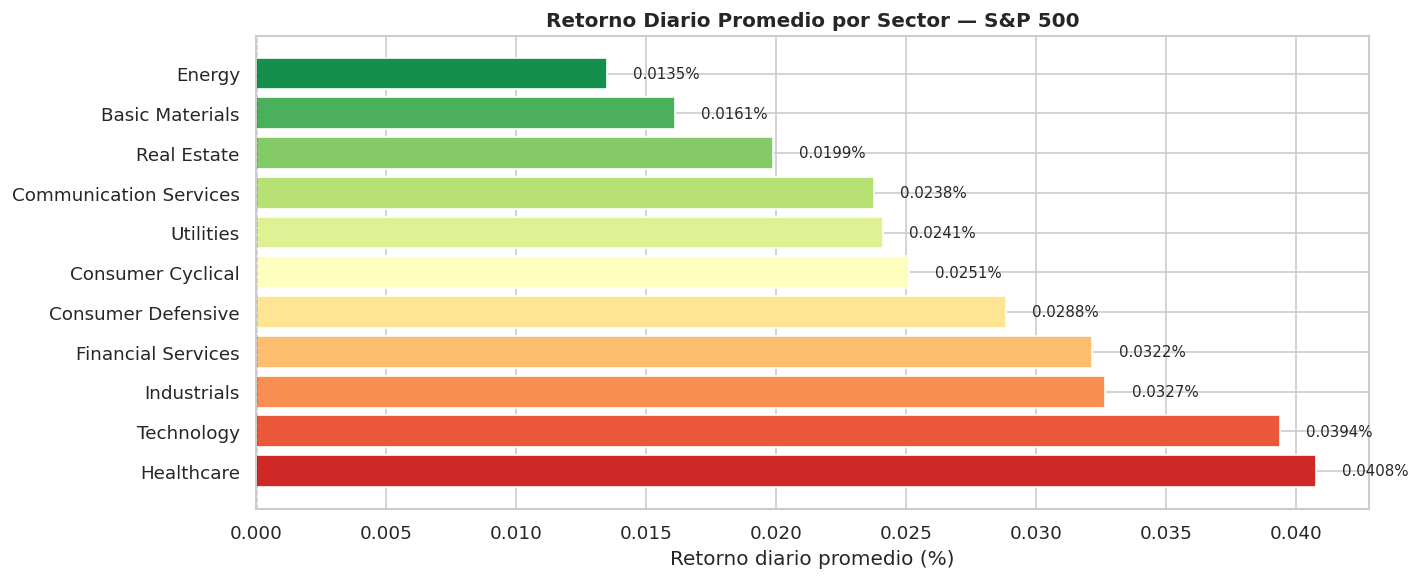

In [49]:
retorno_sector = df.groupby('Sector')['daily_return'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots()
bars = ax.barh(retorno_sector.index, retorno_sector.values, color=sns.color_palette('RdYlGn', len(retorno_sector)))
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Retorno diario promedio (%)')
ax.set_title('Retorno Diario Promedio por Sector — S&P 500', fontweight='bold')

for bar, val in zip(bars, retorno_sector.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_retorno_sector.png', dpi=150)
plt.show()

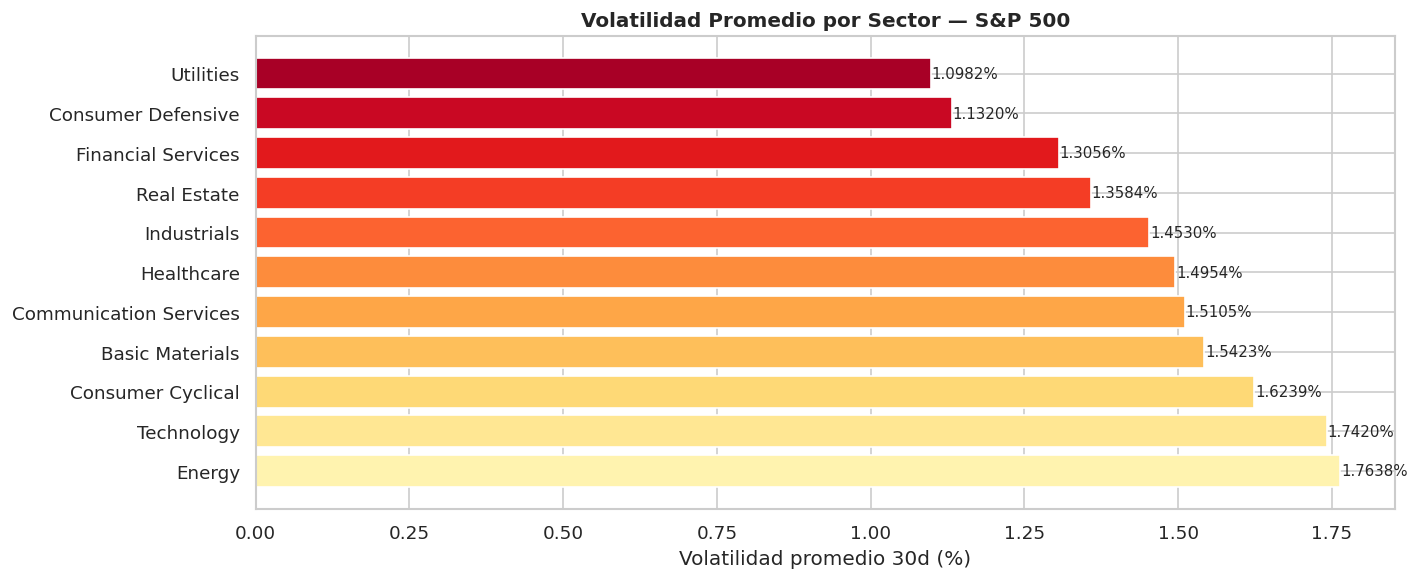

In [50]:
vol_sector = df.groupby('Sector')['volatility_30d'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots()
bars = ax.barh(vol_sector.index, vol_sector.values, color=sns.color_palette('YlOrRd', len(vol_sector)))
ax.set_xlabel('Volatilidad promedio 30d (%)')
ax.set_title('Volatilidad Promedio por Sector — S&P 500', fontweight='bold')

for bar, val in zip(bars, vol_sector.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_volatilidad_sector.png', dpi=150)
plt.show()

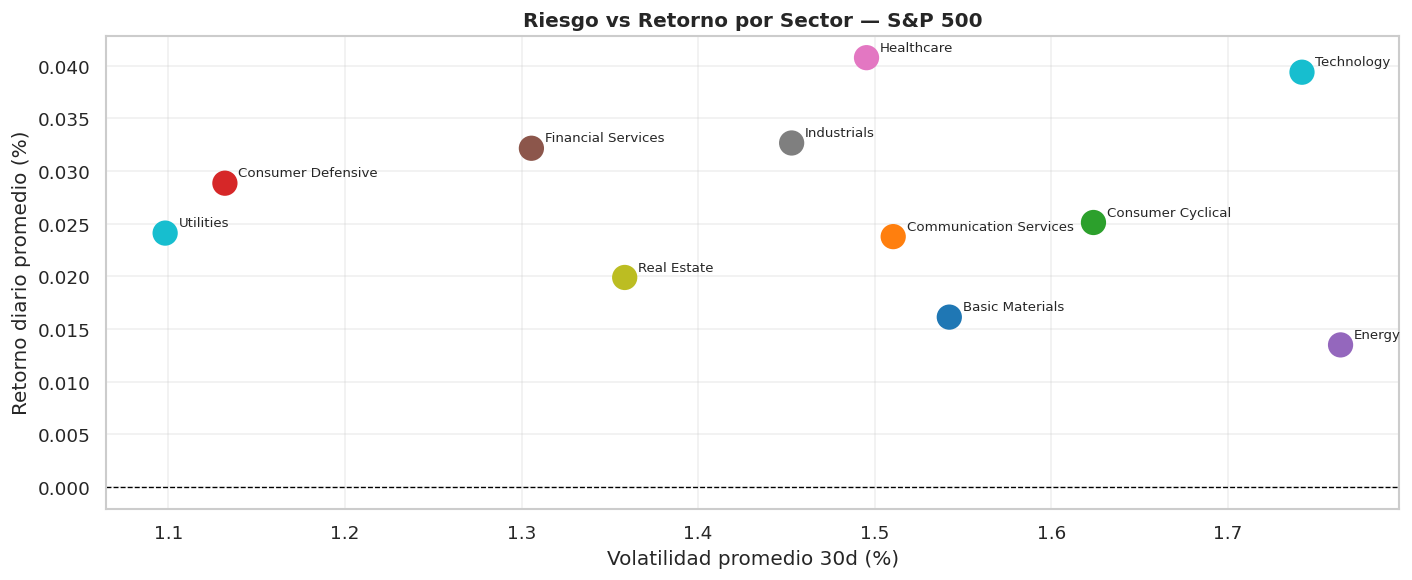

In [51]:
resumen = df.groupby('Sector').agg(
    retorno_promedio=('daily_return', 'mean'),
    volatilidad_promedio=('volatility_30d', 'mean')
).reset_index()

fig, ax = plt.subplots()
scatter = ax.scatter(
    resumen['volatilidad_promedio'] * 100,
    resumen['retorno_promedio'] * 100,
    s=200, c=range(len(resumen)),
    cmap='tab10', zorder=3
)

for _, row in resumen.iterrows():
    ax.annotate(row['Sector'],
                (row['volatilidad_promedio'] * 100, row['retorno_promedio'] * 100),
                textcoords='offset points', xytext=(8, 4), fontsize=8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Volatilidad promedio 30d (%)')
ax.set_ylabel('Retorno diario promedio (%)')
ax.set_title('Riesgo vs Retorno por Sector — S&P 500', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_riesgo_retorno.png', dpi=150)
plt.show()

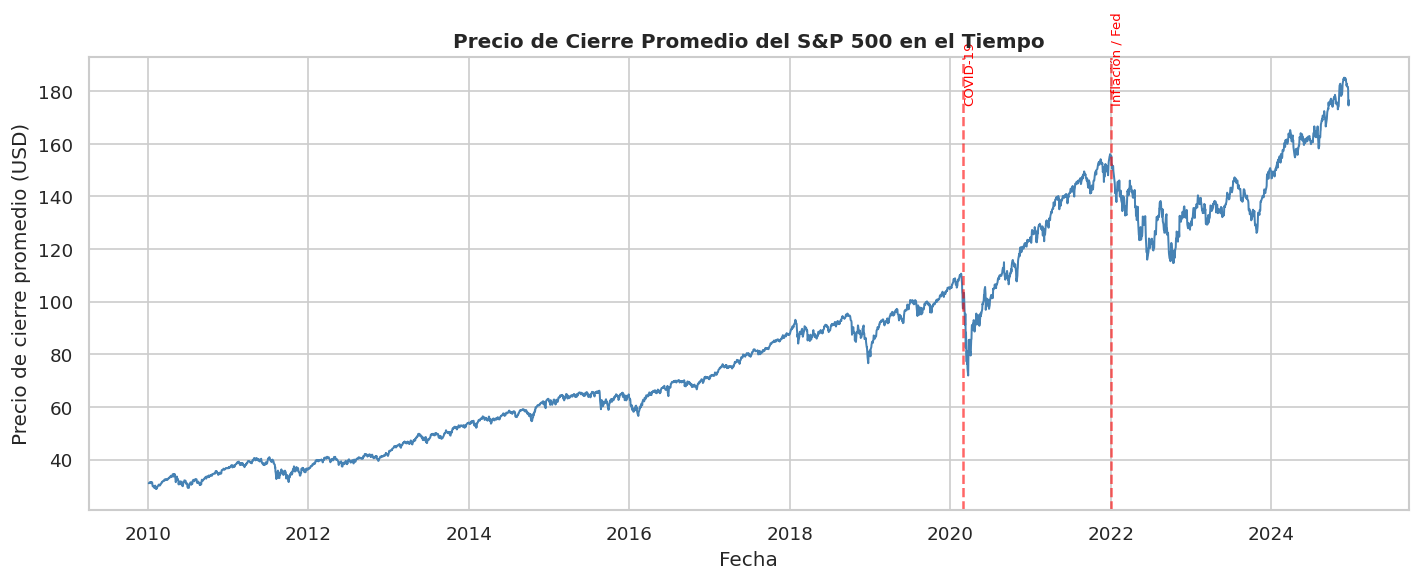

In [52]:
evolucion = df.groupby('Date')['Close'].mean()

fig, ax = plt.subplots()
ax.plot(evolucion.index, evolucion.values, color='steelblue', linewidth=1.2)
ax.set_title('Precio de Cierre Promedio del S&P 500 en el Tiempo', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio de cierre promedio (USD)')

# Marcar eventos clave
eventos = {
    '2020-03-01': 'COVID-19',
    '2022-01-01': 'Inflación / Fed'
}
for fecha, label in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color='red', linestyle='--', alpha=0.6)
    ax.text(pd.Timestamp(fecha), evolucion.max() * 0.95, label,
            rotation=90, color='red', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_evolucion_temporal.png', dpi=150)
plt.show()

/tmp/ipykernel_1463/222094461.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  retorno_acumulado = df.groupby(['Symbol', 'Sector']).apply(


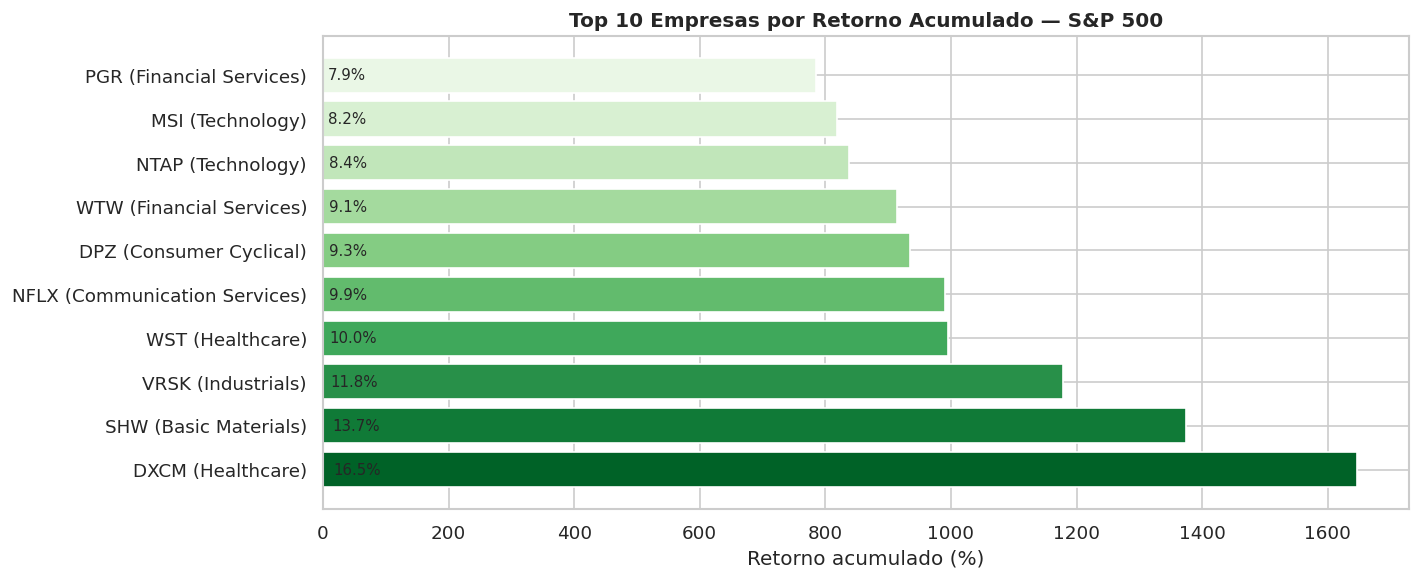

In [53]:
# Retorno acumulado por empresa
retorno_acumulado = df.groupby(['Symbol', 'Sector']).apply(
    lambda x: (1 + x['daily_return']).prod() - 1
).reset_index(name='retorno_acumulado')

top10 = retorno_acumulado.sort_values('retorno_acumulado', ascending=False).head(10)

fig, ax = plt.subplots()
bars = ax.barh(
    top10['Symbol'] + ' (' + top10['Sector'] + ')',
    top10['retorno_acumulado'] * 100,
    color=sns.color_palette('Greens_r', 10)
)
ax.set_xlabel('Retorno acumulado (%)')
ax.set_title('Top 10 Empresas por Retorno Acumulado — S&P 500', fontweight='bold')

for bar, val in zip(bars, top10['retorno_acumulado'].values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_top10_retorno.png', dpi=150)
plt.show()

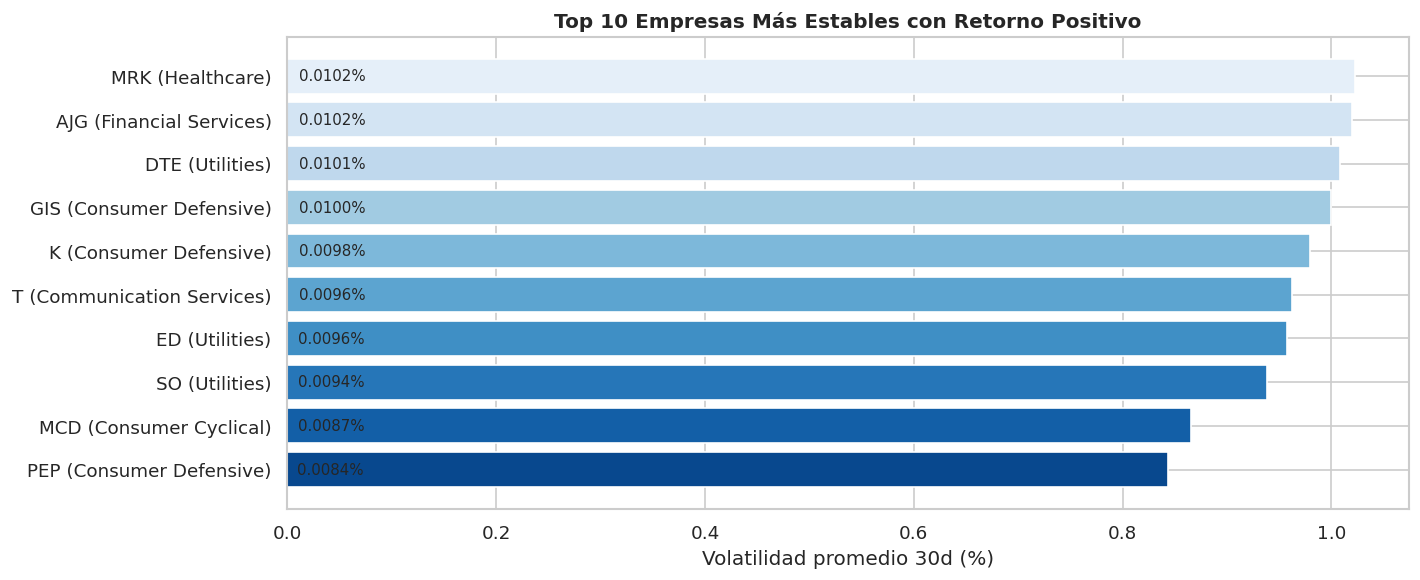

In [54]:
resumen_empresas = df.groupby(['Symbol', 'Sector']).agg(
    retorno_promedio=('daily_return', 'mean'),
    volatilidad=('volatility_30d', 'mean')
).reset_index().dropna()

# Filtrar solo empresas con retorno positivo
estables = resumen_empresas[resumen_empresas['retorno_promedio'] > 0]
estables = estables.sort_values('volatilidad').head(10)

fig, ax = plt.subplots()
bars = ax.barh(
    estables['Symbol'] + ' (' + estables['Sector'] + ')',
    estables['volatilidad'] * 100,
    color=sns.color_palette('Blues_r', 10)
)
ax.set_xlabel('Volatilidad promedio 30d (%)')
ax.set_title('Top 10 Empresas Más Estables con Retorno Positivo', fontweight='bold')

for bar, val in zip(bars, estables['volatilidad'].values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_top10_estables.png', dpi=150)
plt.show()

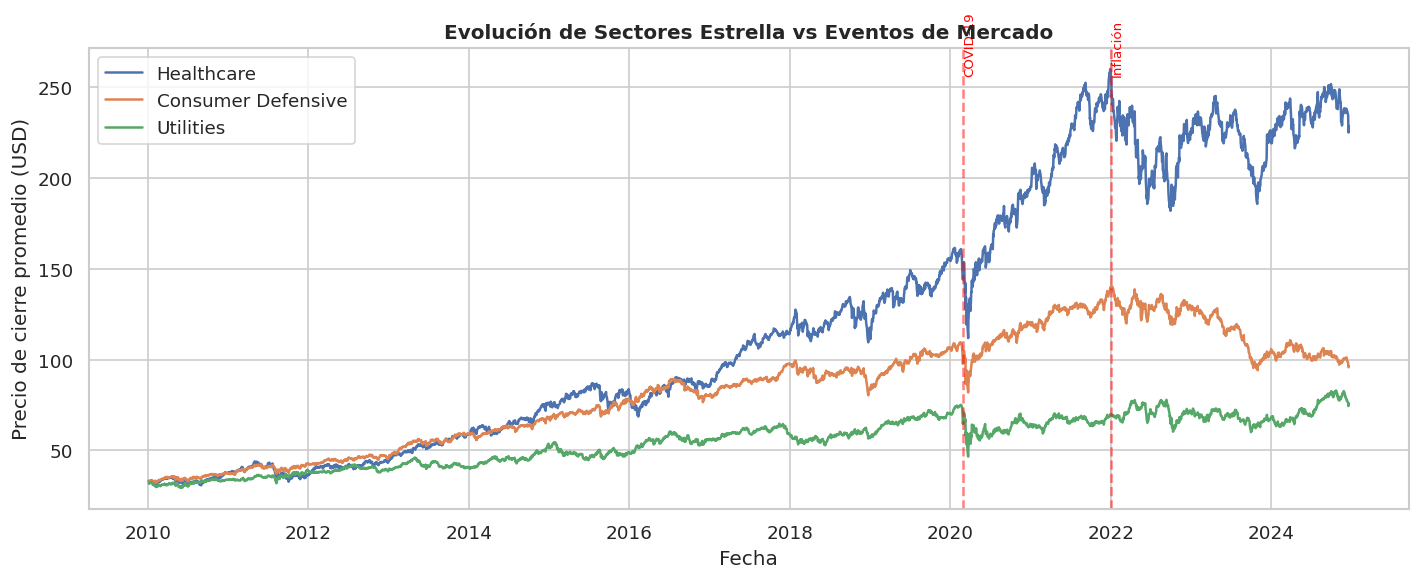

In [55]:
sectores_estrella = ['Healthcare', 'Consumer Defensive', 'Utilities']

evolucion_sectores = df[df['Sector'].isin(sectores_estrella)].groupby(
    ['Date', 'Sector']
)['Close'].mean().reset_index()

fig, ax = plt.subplots()
for sector in sectores_estrella:
    data = evolucion_sectores[evolucion_sectores['Sector'] == sector]
    ax.plot(data['Date'], data['Close'], label=sector, linewidth=1.5)

# Marcar eventos clave
for fecha, label in [('2020-03-01', 'COVID-19'), ('2022-01-01', 'Inflación')]:
    ax.axvline(pd.Timestamp(fecha), color='red', linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(fecha), ax.get_ylim()[1] * 0.95,
            label, rotation=90, color='red', fontsize=8)

ax.set_title('Evolución de Sectores Estrella vs Eventos de Mercado', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio de cierre promedio (USD)')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_sectores_estrella.png', dpi=150)
plt.show()

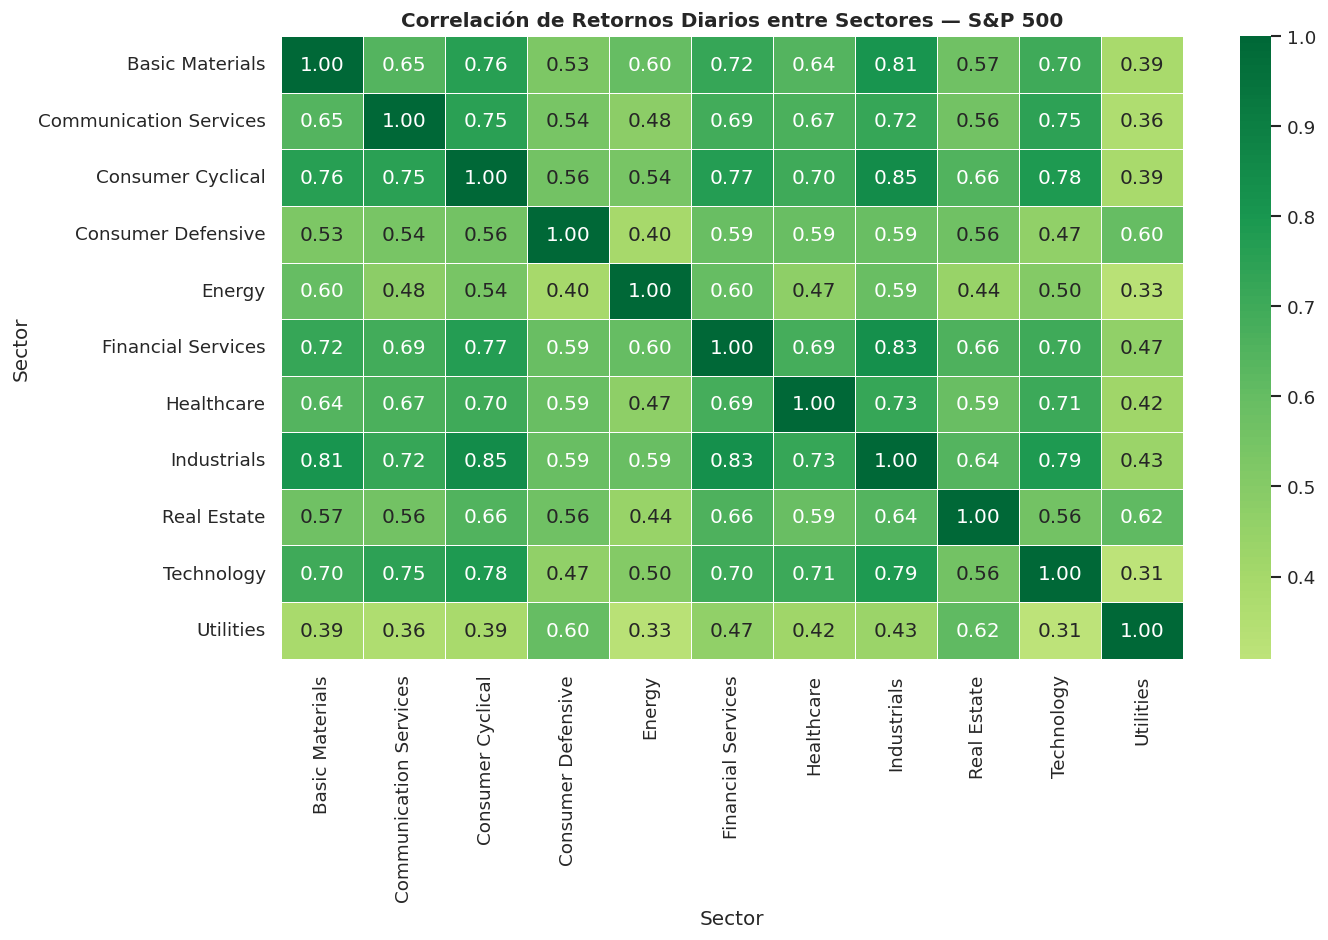

In [56]:
pivot = df.groupby(['Date', 'Sector'])['daily_return'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    pivot.corr(),
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlación de Retornos Diarios entre Sectores — S&P 500', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_correlacion_sectores.png', dpi=150)
plt.show()

In [57]:
# Usamos Healthcare como sector estrella para el modelo
ticker = 'ABBV'  # UnitedHealth, empresa líder de Healthcare en S&P 500

df_ticker = df[df['Symbol'] == ticker].copy().dropna(subset=['MA_20', 'MA_50'])

# Señal: 1 = compra (MA20 cruza hacia arriba MA50), 0 = fuera del mercado
df_ticker['signal'] = 0
df_ticker.loc[df_ticker['MA_20'] > df_ticker['MA_50'], 'signal'] = 1

# Retorno de la estrategia vs buy & hold
df_ticker['strategy_return'] = df_ticker['signal'].shift(1) * df_ticker['daily_return']
df_ticker['cumulative_market'] = (1 + df_ticker['daily_return']).cumprod()
df_ticker['cumulative_strategy'] = (1 + df_ticker['strategy_return']).cumprod()

print(f"Retorno acumulado Buy & Hold: {(df_ticker['cumulative_market'].iloc[-1] - 1) * 100:.1f}%")
print(f"Retorno acumulado Estrategia MA: {(df_ticker['cumulative_strategy'].iloc[-1] - 1) * 100:.1f}%")

Retorno acumulado Buy & Hold: 232.1%
Retorno acumulado Estrategia MA: 70.8%


In [58]:
tickers_healthcare = df[df['Sector'] == 'Healthcare']['Symbol'].unique()
print(f"Tickers de Healthcare disponibles: {len(tickers_healthcare)}")
print(sorted(tickers_healthcare))

Tickers de Healthcare disponibles: 21
['ABBV', 'ABT', 'BAX', 'BDX', 'BSX', 'DXCM', 'HCA', 'HSIC', 'INCY', 'IQV', 'ISRG', 'LH', 'MRK', 'MTD', 'PODD', 'RVTY', 'SOLV', 'UHS', 'VRTX', 'VTRS', 'WST']


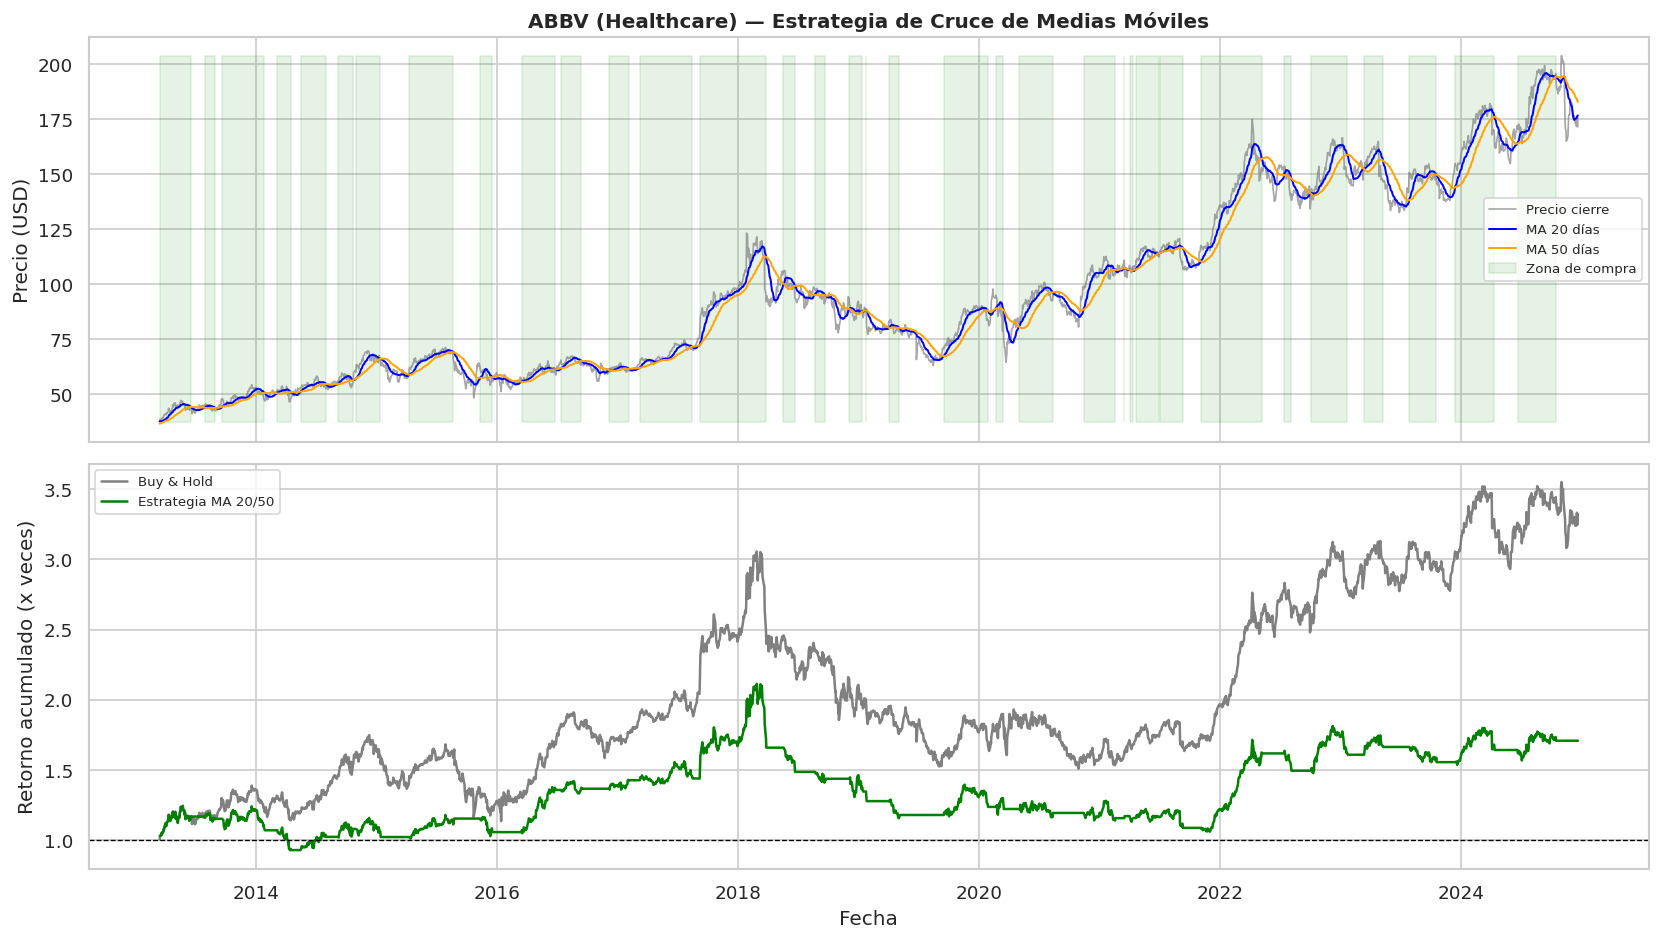

In [59]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel superior: precio con medias móviles y señales
ax1.plot(df_ticker['Date'], df_ticker['Close'], label='Precio cierre', color='gray', linewidth=1, alpha=0.7)
ax1.plot(df_ticker['Date'], df_ticker['MA_20'], label='MA 20 días', color='blue', linewidth=1.2)
ax1.plot(df_ticker['Date'], df_ticker['MA_50'], label='MA 50 días', color='orange', linewidth=1.2)

# Marcar zonas de compra
ax1.fill_between(df_ticker['Date'], df_ticker['Close'].min(), df_ticker['Close'].max(),
                 where=df_ticker['signal'] == 1,
                 alpha=0.1, color='green', label='Zona de compra')

ax1.set_title('ABBV (Healthcare) — Estrategia de Cruce de Medias Móviles', fontweight='bold')
ax1.set_ylabel('Precio (USD)')
ax1.legend(fontsize=8)

# Panel inferior: retorno acumulado comparativo
ax2.plot(df_ticker['Date'], df_ticker['cumulative_market'], label='Buy & Hold', color='gray', linewidth=1.5)
ax2.plot(df_ticker['Date'], df_ticker['cumulative_strategy'], label='Estrategia MA 20/50', color='green', linewidth=1.5)
ax2.set_ylabel('Retorno acumulado (x veces)')
ax2.set_xlabel('Fecha')
ax2.legend(fontsize=8)
ax2.axhline(1, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_modelo_predictivo.png', dpi=150)
plt.show()

In [60]:
# Días en el mercado
dias_activo = df_ticker['signal'].sum()
dias_total = len(df_ticker)

# Máxima caída (drawdown)
rolling_max = df_ticker['cumulative_strategy'].cummax()
drawdown = (df_ticker['cumulative_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min() * 100

retorno_bh = (df_ticker['cumulative_market'].iloc[-1] - 1) * 100
retorno_ma = (df_ticker['cumulative_strategy'].iloc[-1] - 1) * 100

print("=" * 45)
print("        RESUMEN DEL MODELO PREDICTIVO")
print("=" * 45)
print(f"  Ticker analizado       : ABBV (Healthcare)")
print(f"  Días activo en mercado : {dias_activo} de {dias_total} ({dias_activo/dias_total*100:.1f}%)")
print(f"  Retorno Buy & Hold     : {retorno_bh:.1f}%")
print(f"  Retorno Estrategia MA  : {retorno_ma:.1f}%")
print(f"  Diferencia             : {retorno_ma - retorno_bh:.1f}%")
print(f"  Máx. caída estrategia  : {max_drawdown:.1f}%")
print("=" * 45)

        RESUMEN DEL MODELO PREDICTIVO
  Ticker analizado       : ABBV (Healthcare)
  Días activo en mercado : 1791 de 2965 (60.4%)
  Retorno Buy & Hold     : 232.1%
  Retorno Estrategia MA  : 70.8%
  Diferencia             : -161.3%
  Máx. caída estrategia  : -49.9%


In [61]:
volatilidad_tickers = df[df['Sector'] == 'Healthcare'].groupby('Symbol')['volatility_30d'].mean().sort_values(ascending=False)
print(volatilidad_tickers)

Symbol
DXCM    0.022776
INCY    0.021753
PODD    0.021531
SOLV    0.018875
VRTX    0.018594
VTRS    0.017462
HCA     0.016024
UHS     0.015998
ISRG    0.014899
BSX     0.014080
IQV     0.014043
MTD     0.013918
WST     0.013875
RVTY    0.013564
ABBV    0.013074
HSIC    0.012276
LH      0.011727
BAX     0.011556
ABT     0.010654
BDX     0.010379
MRK     0.010231
Name: volatility_30d, dtype: float64


In [62]:
#Análisis DXCM

In [63]:
# Usamos Healthcare como sector estrella para el modelo
ticker = 'DXCM'  # UnitedHealth, empresa líder de Healthcare en S&P 500

df_ticker = df[df['Symbol'] == ticker].copy().dropna(subset=['MA_20', 'MA_50'])

# Señal: 1 = compra (MA20 cruza hacia arriba MA50), 0 = fuera del mercado
df_ticker['signal'] = 0
df_ticker.loc[df_ticker['MA_20'] > df_ticker['MA_50'], 'signal'] = 1

# Retorno de la estrategia vs buy & hold
df_ticker['strategy_return'] = df_ticker['signal'].shift(1) * df_ticker['daily_return']
df_ticker['cumulative_market'] = (1 + df_ticker['daily_return']).cumprod()
df_ticker['cumulative_strategy'] = (1 + df_ticker['strategy_return']).cumprod()

print(f"Retorno acumulado Buy & Hold: {(df_ticker['cumulative_market'].iloc[-1] - 1) * 100:.1f}%")
print(f"Retorno acumulado Estrategia MA: {(df_ticker['cumulative_strategy'].iloc[-1] - 1) * 100:.1f}%")

Retorno acumulado Buy & Hold: 1466.5%
Retorno acumulado Estrategia MA: 313.7%


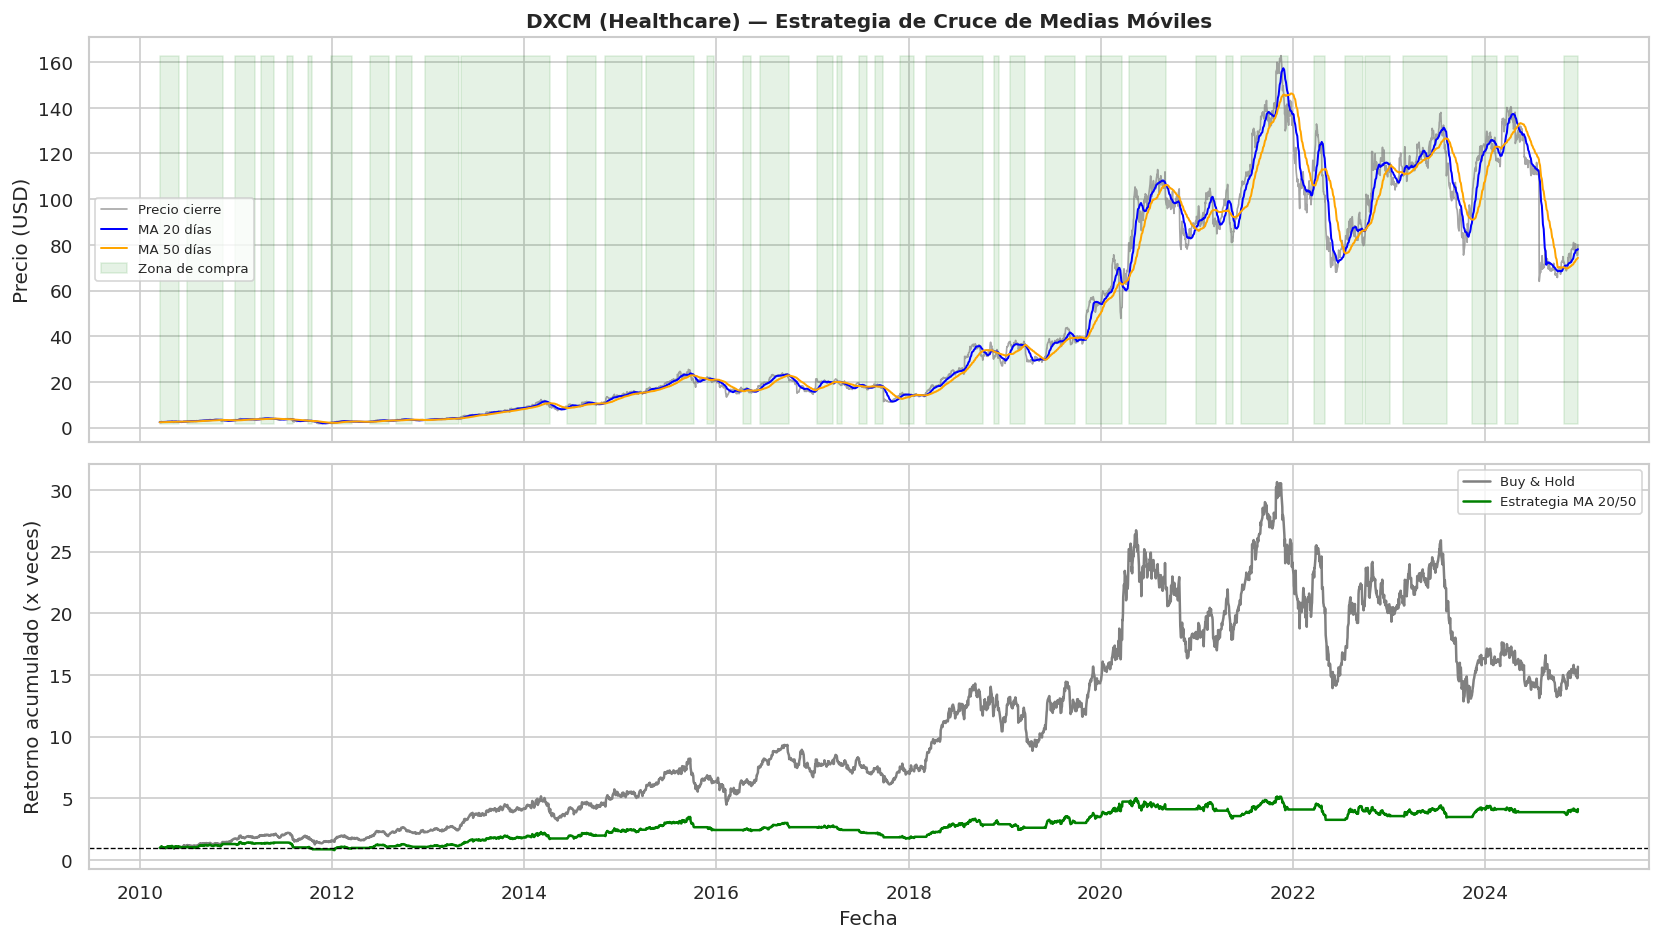

In [64]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel superior: precio con medias móviles y señales
ax1.plot(df_ticker['Date'], df_ticker['Close'], label='Precio cierre', color='gray', linewidth=1, alpha=0.7)
ax1.plot(df_ticker['Date'], df_ticker['MA_20'], label='MA 20 días', color='blue', linewidth=1.2)
ax1.plot(df_ticker['Date'], df_ticker['MA_50'], label='MA 50 días', color='orange', linewidth=1.2)

# Marcar zonas de compra
ax1.fill_between(df_ticker['Date'], df_ticker['Close'].min(), df_ticker['Close'].max(),
                 where=df_ticker['signal'] == 1,
                 alpha=0.1, color='green', label='Zona de compra')

ax1.set_title('DXCM (Healthcare) — Estrategia de Cruce de Medias Móviles', fontweight='bold')
ax1.set_ylabel('Precio (USD)')
ax1.legend(fontsize=8)

# Panel inferior: retorno acumulado comparativo
ax2.plot(df_ticker['Date'], df_ticker['cumulative_market'], label='Buy & Hold', color='gray', linewidth=1.5)
ax2.plot(df_ticker['Date'], df_ticker['cumulative_strategy'], label='Estrategia MA 20/50', color='green', linewidth=1.5)
ax2.set_ylabel('Retorno acumulado (x veces)')
ax2.set_xlabel('Fecha')
ax2.legend(fontsize=8)
ax2.axhline(1, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_modelo_predictivo.png', dpi=150)
plt.show()

In [65]:
# Días en el mercado
dias_activo = df_ticker['signal'].sum()
dias_total = len(df_ticker)

# Máxima caída (drawdown)
rolling_max = df_ticker['cumulative_strategy'].cummax()
drawdown = (df_ticker['cumulative_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min() * 100

retorno_bh = (df_ticker['cumulative_market'].iloc[-1] - 1) * 100
retorno_ma = (df_ticker['cumulative_strategy'].iloc[-1] - 1) * 100

print("=" * 45)
print("        RESUMEN DEL MODELO PREDICTIVO")
print("=" * 45)
print(f"  Ticker analizado       : DXCM (Healthcare)")
print(f"  Días activo en mercado : {dias_activo} de {dias_total} ({dias_activo/dias_total*100:.1f}%)")
print(f"  Retorno Buy & Hold     : {retorno_bh:.1f}%")
print(f"  Retorno Estrategia MA  : {retorno_ma:.1f}%")
print(f"  Diferencia             : {retorno_ma - retorno_bh:.1f}%")
print(f"  Máx. caída estrategia  : {max_drawdown:.1f}%")
print("=" * 45)

        RESUMEN DEL MODELO PREDICTIVO
  Ticker analizado       : DXCM (Healthcare)
  Días activo en mercado : 2365 de 3719 (63.6%)
  Retorno Buy & Hold     : 1466.5%
  Retorno Estrategia MA  : 313.7%
  Diferencia             : -1152.8%
  Máx. caída estrategia  : -50.6%


In [68]:
# Retorno acumulado PROMEDIO por sector (correcto)
retorno_sector_acum = df.groupby(['Sector', 'Symbol']).apply(
    lambda x: (1 + x['daily_return']).prod() - 1
).reset_index(name='retorno_acumulado')

retorno_sector_acum = retorno_sector_acum.groupby('Sector')['retorno_acumulado'].mean() * 100

# Volatilidad promedio por sector
vol_sector = df.groupby('Sector')['volatility_30d'].mean() * 100

# Tabla resumen ejecutiva
resumen_final = pd.DataFrame({
    'Retorno Acumulado (%)': retorno_sector_acum.round(1),
    'Volatilidad Promedio (%)': vol_sector.round(4)
}).sort_values('Retorno Acumulado (%)', ascending=False)

print("=== TABLA RESUMEN EJECUTIVA ===")
display(resumen_final)

=== TABLA RESUMEN EJECUTIVA ===


/tmp/ipykernel_1463/4292426154.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  retorno_sector_acum = df.groupby(['Sector', 'Symbol']).apply(


,Retorno Acumulado (%),Volatilidad Promedio (%)
Sector,,
Healthcare,293.2,1.4954
Technology,253.3,1.7420
Financial Services,224.7,1.3056
Basic Materials,198.9,1.5423
Industrials,179.9,1.4530
Consumer Defensive,146.3,1.1320
Utilities,126.4,1.0982
Communication Services,116.3,1.5105
Consumer Cyclical,102.9,1.6239


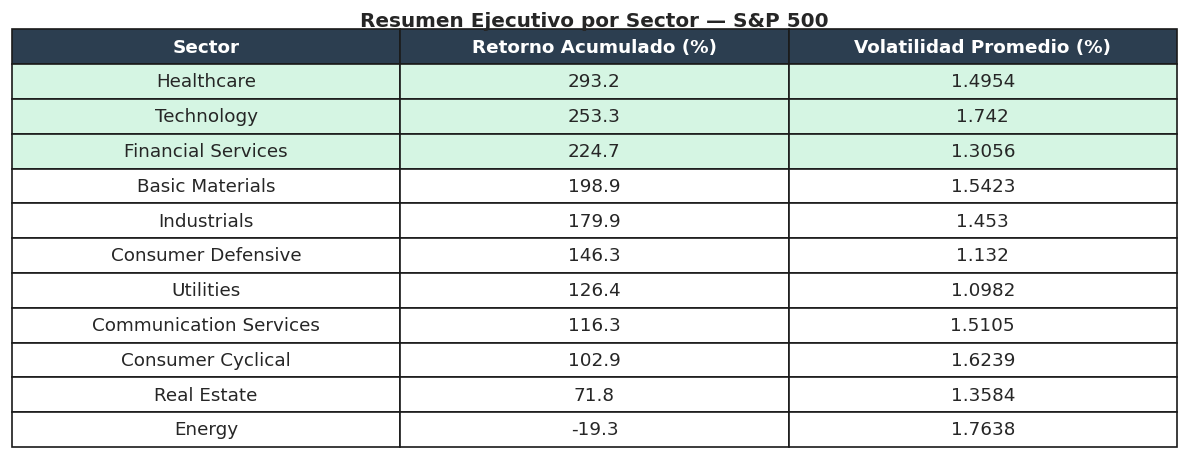

In [69]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

tabla = ax.table(
    cellText=resumen_final.reset_index().values,
    colLabels=['Sector', 'Retorno Acumulado (%)', 'Volatilidad Promedio (%)'],
    cellLoc='center',
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 1.8)

# Colorear encabezados
for j in range(3):
    tabla[0, j].set_facecolor('#2C3E50')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# Colorear top 3
for j in range(3):
    tabla[1, j].set_facecolor('#D5F5E3')
    tabla[2, j].set_facecolor('#D5F5E3')
    tabla[3, j].set_facecolor('#D5F5E3')

ax.set_title('Resumen Ejecutivo por Sector — S&P 500', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_tabla_resumen.png', dpi=150, bbox_inches='tight')
plt.show()